In [5]:
from obspy.taup.taup_create import build_taup_model

build_taup_model("/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel")

Building obspy.taup model for '/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel' ...
filename = /Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel
Done reading velocity model.
Radius of model  is 1737.1
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  985 P layers,937 S layers
Done calculating Tau branches.
Done Saving /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/.venv/lib/python3.13/site-packages/obspy/taup/data/vpremoon_mantle_closed.npz
Method run is done, but not necessarily successful.


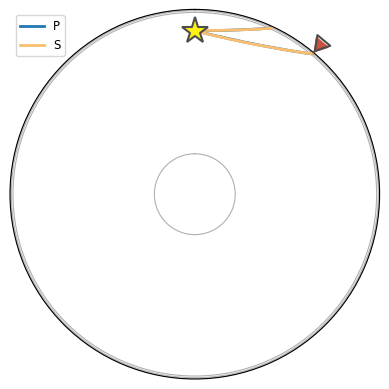

<PolarAxes: >

In [11]:
from obspy.taup import TauPyModel

model = TauPyModel(model="vpremoon_mantle_closed")

arrivals = model.get_ray_paths(
    source_depth_in_km=200,
    distance_in_degree=40,
    phase_list=["P", "S"]
)
arrivals.plot_rays(plot_type="spherical", legend=True)

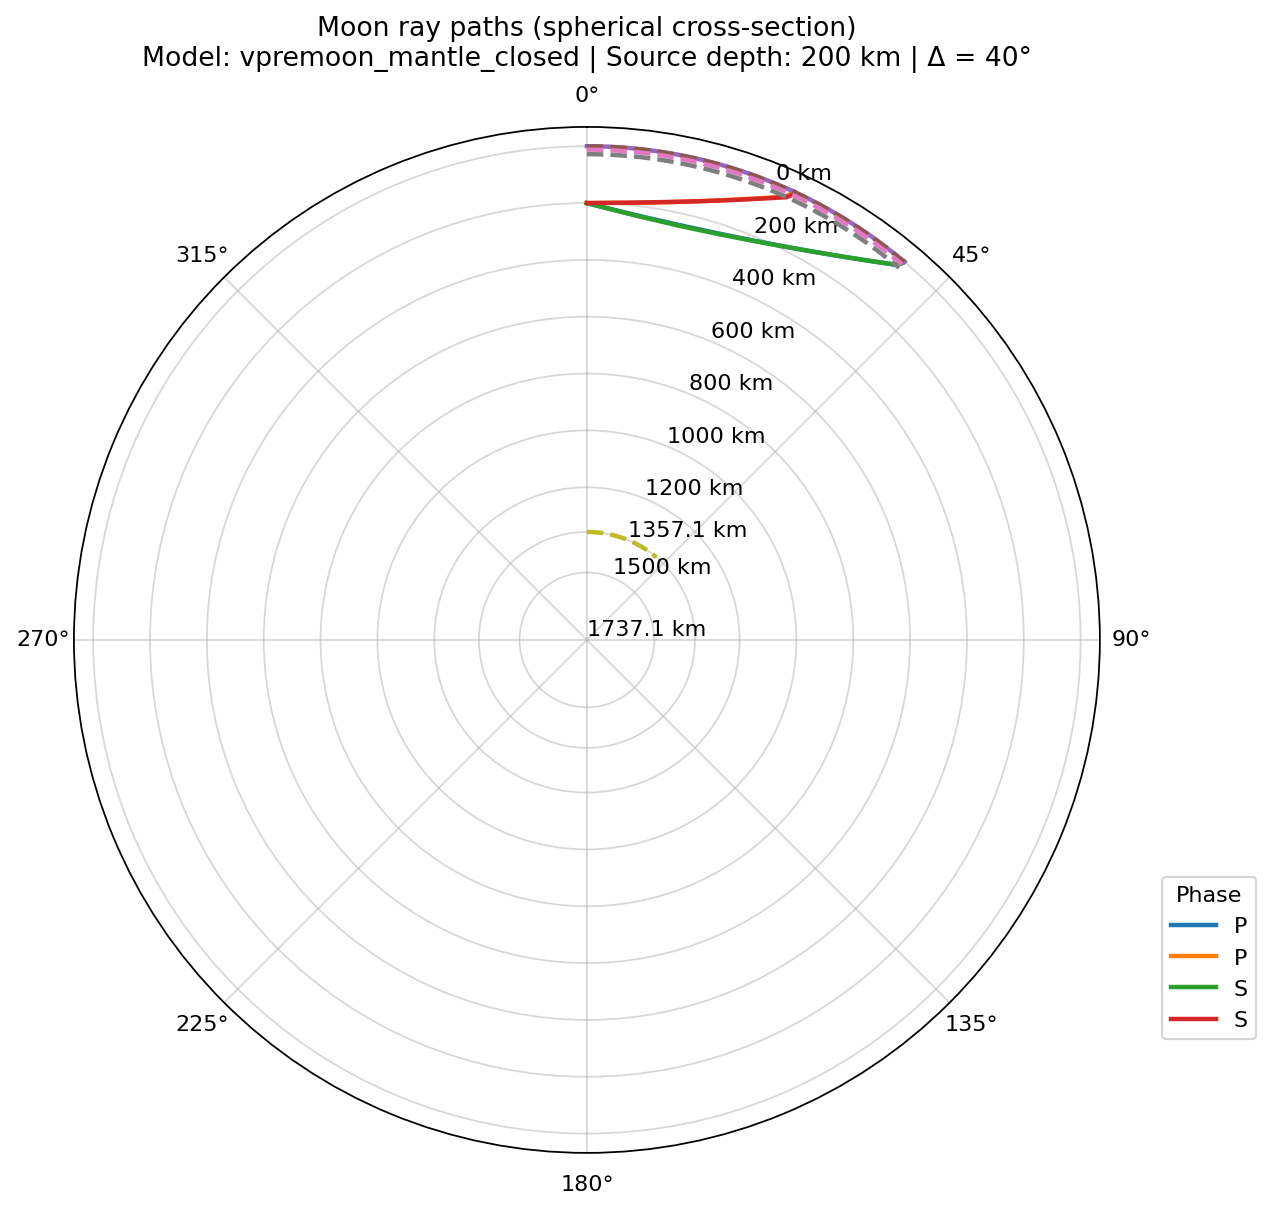

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel

# ---------- user settings ----------
MODEL_NAME = "vpremoon_mantle_closed"     # or full path to .npz
TVEL_PATH  = "/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel"  # for boundary detection
RMOON_KM    = 1737.1

SOURCE_DEPTH_KM = 200
DIST_DEG        = 40
PHASES          = ["P", "S"]

# depth tick marks you want to see on the plot (km)
DEPTH_TICKS_KM = [0, 200, 400, 600, 800, 1000, 1200, 1357.1, 1500, 1737.1]
# ----------------------------------


def infer_boundaries_from_tvel(tvel_path, tol=1e-9):
    """Boundaries are duplicated depths in a .tvel (top/bottom of discontinuity)."""
    depths = []
    with open(tvel_path, "r") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith(("VPREMOON", "depth_km")):
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                depths.append(float(parts[0]))
            except ValueError:
                pass

    depths = np.array(sorted(depths))
    dup_idx = np.where(np.abs(np.diff(depths)) < tol)[0]
    return sorted(set(depths[dup_idx].tolist()))


model = TauPyModel(model=MODEL_NAME)
arrivals = model.get_ray_paths(
    source_depth_in_km=SOURCE_DEPTH_KM,
    distance_in_degree=DIST_DEG,
    phase_list=PHASES
)

# Boundaries from .tvel + force the mantle/unknown-core boundary we know exists
boundaries_km = []
try:
    boundaries_km = infer_boundaries_from_tvel(TVEL_PATH)
except Exception:
    boundaries_km = []

if 1357.1 not in boundaries_km:
    boundaries_km.append(1357.1)
boundaries_km = sorted(set(boundaries_km))

# ----- Plot -----
fig = plt.figure(figsize=(8, 8), dpi=160)
ax = plt.subplot(111, projection="polar")

# Put 0° at the top and increase clockwise (nice for "planet cross-section" feel)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Plot each ray
for a in arrivals:
    path = a.path
    theta = path["dist"]                 # radians
    r = RMOON_KM - path["depth"]         # radius from center (km)
    ax.plot(theta, r, linewidth=2, label=a.name)

# Draw outer surface circle (Moon surface)
theta_grid = np.linspace(0, np.deg2rad(DIST_DEG), 400)
ax.plot(theta_grid, np.full_like(theta_grid, RMOON_KM), linewidth=2)

# Draw boundary circles
for d in boundaries_km:
    rb = RMOON_KM - d
    ax.plot(theta_grid, np.full_like(theta_grid, rb), linestyle="--", linewidth=2)

# Radial ticks labeled as DEPTH (not radius)
depth_ticks = [d for d in DEPTH_TICKS_KM if 0 <= d <= RMOON_KM]
r_ticks = [RMOON_KM - d for d in depth_ticks]
ax.set_yticks(r_ticks)
ax.set_yticklabels([f"{d:g} km" for d in depth_ticks])

# Limit angular extent to the requested epicentral distance
# ax.set_thetamin(0)
# ax.set_thetamax(DIST_DEG)

# Cosmetic / labels
ax.set_title(
    f"Moon ray paths (spherical cross-section)\n"
    f"Model: {MODEL_NAME} | Source depth: {SOURCE_DEPTH_KM} km | Δ = {DIST_DEG}°",
    va="bottom"
)
ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.1), title="Phase")
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

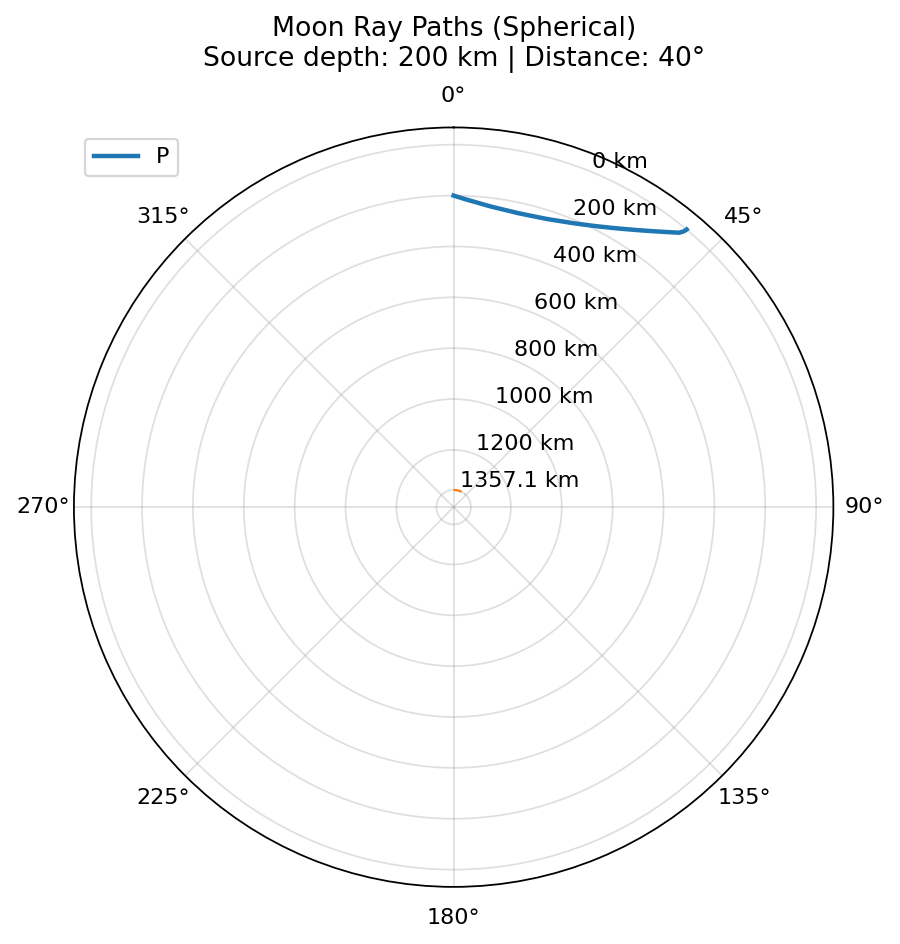

P ends at 40.00000008108198


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel

MODEL_NAME = "vpremoon_mantle_closed"
RMOON_KM = 1737.1
SOURCE_DEPTH = 200
DIST_DEG = 40
TOL = 1e-3

model = TauPyModel(model=MODEL_NAME)

arr_all = model.get_ray_paths(
    source_depth_in_km=SOURCE_DEPTH,
    distance_in_degree=DIST_DEG,
    phase_list=["P"]
)

# Filter: keep only rays whose last point is at ~DIST_DEG
arr = [a for a in arr_all if abs(np.degrees(a.path["dist"][-1]) - DIST_DEG) < TOL]

# ---- Make a spherical (polar) plot manually ----
fig = plt.figure(figsize=(6, 6), dpi=160)
ax = plt.subplot(111, projection="polar")

# Match TauP's typical polar orientation
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Plot rays
for a in arr:
    theta = a.path["dist"]                 # radians
    r = RMOON_KM - a.path["depth"]         # radius (km)
    ax.plot(theta, r, linewidth=2, label=a.name)

# Limit to the wedge 0..DIST_DEG
# ax.set_thetamin(0)
# ax.set_thetamax(DIST_DEG)

# Depth ticks (labels are depth, not radius)
depth_ticks = [0, 200, 400, 600, 800, 1000, 1200, 1357.1, 1500, 1737.1]
r_ticks = [RMOON_KM - d for d in depth_ticks]
ax.set_yticks(r_ticks)
ax.set_yticklabels([f"{d:g} km" for d in depth_ticks])

# Boundary circle at mantle / unknown-core boundary
theta_grid = np.linspace(0, np.deg2rad(DIST_DEG), 600)
mantle_boundary_depth = 1357.1
r_boundary = RMOON_KM - mantle_boundary_depth
ax.plot(theta_grid, np.full_like(theta_grid, r_boundary), linestyle="--", linewidth=1)

# Title/grid/legend
ax.set_title(
    f"Moon Ray Paths (Spherical)\nSource depth: {SOURCE_DEPTH} km | Distance: {DIST_DEG}°",
    va="bottom"
)
ax.grid(True, alpha=0.4)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Print endpoints once
for a in arr:
    print(a.name, "ends at", np.degrees(a.path["dist"][-1]))

In [26]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


Matched 43 Excel events to MiniSEED traces (tol=2.0s).
 Kept by dt_rel criteria: 5/43
Kept with MiniSEED match: 5/5
LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0 
 Selected events (time_utc, station, epi_deg):
                                event                         time_utc station    epi_deg
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:29:00.023000+00:00     S14  46.000000
1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00     S14  56.580047
1975-01-03 01:32:00.013000+00:00__S15 1975-01-03 01:47:03.344000+00:00     S15  83.980853
1973-03-13 07:47:00.014000+00:00__S14 1973-03-13 08:01:35.960000+00:00     S14  88.890000
1974-07-11 00:37:00.006000+00:00__S14 1974-07-11 00:52:15.850000+00:00     S14 100.704577


In [28]:
# ============================================================
# Event selection only (no plotting)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print + SAVE: per scenario list of selected events
#   (time, station, epicentral distance, lat, Lon)
# ============================================================

import os
import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
]

# where to save the selected event lists
OUT_DIR = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def _first_existing_col(cols, candidates):
    """Return the first candidate name that exists in cols, else None."""
    for c in candidates:
        if c in cols:
            return c
    return None


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    # distance
    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    # lat / Lon (support common variants)
    lat_col = _first_existing_col(d.columns, ["lat", "Lat", "LAT", "latitude", "Latitude"])
    lon_col = _first_existing_col(d.columns, ["Lon", "lon", "LON", "longitude", "Longitude"])

    if lat_col is not None:
        d["lat"] = pd.to_numeric(d[lat_col], errors="coerce")
    else:
        d["lat"] = np.nan

    if lon_col is not None:
        d["Lon"] = pd.to_numeric(d[lon_col], errors="coerce")
    else:
        d["Lon"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "lat", "Lon", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

# event-level distance / lat / Lon (same pattern as epi_deg)
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)
lat_map = (
    df_long[["event", "lat"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["lat"]
    .to_dict()
)
lon_map = (
    df_long[["event", "Lon"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["Lon"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(" No events after MiniSEED matching.")
        continue

    # Build table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
            lat=lat_map.get(ev, np.nan),
            Lon=lon_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df["lat"]     = pd.to_numeric(out_df["lat"], errors="coerce")
    out_df["Lon"]     = pd.to_numeric(out_df["Lon"], errors="coerce")

    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print
    print(
        f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS}\n"
        "Selected events (time_utc, station, epi_deg, lat, Lon):"
    )
    print(out_df.to_string(index=False))

    # Save (CSV)
    tag = f"LOW{LOWER_TOL}_MINPOST{MIN_POST}_KNEG{K_NEG}_KPREPOS{K_PRE_POS}".replace(".", "p")
    out_csv = os.path.join(OUT_DIR, f"selected_events_{sheet}_{tag}.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

Matched 43 Excel events to MiniSEED traces (tol=2.0s).
 Kept by dt_rel criteria: 5/43
Kept with MiniSEED match: 5/5
LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0
Selected events (time_utc, station, epi_deg, lat, Lon):
                                event                         time_utc station    epi_deg   lat    Lon
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:29:00.023000+00:00     S14  46.000000  42.0  -24.0
1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00     S14  56.580047  52.5  -25.8
1975-01-03 01:32:00.013000+00:00__S15 1975-01-03 01:47:03.344000+00:00     S15  83.980853  26.1  -92.7
1973-03-13 07:47:00.014000+00:00__S14 1973-03-13 08:01:35.960000+00:00     S14  88.890000 -84.9 -137.1
1974-07-11 00:37:00.006000+00:00__S14 1974-07-11 00:52:15.850000+00:00     S14 100.704577  21.9   82.6
Saved: /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events/selected_events_best_7_bands_fixed_hold0_L

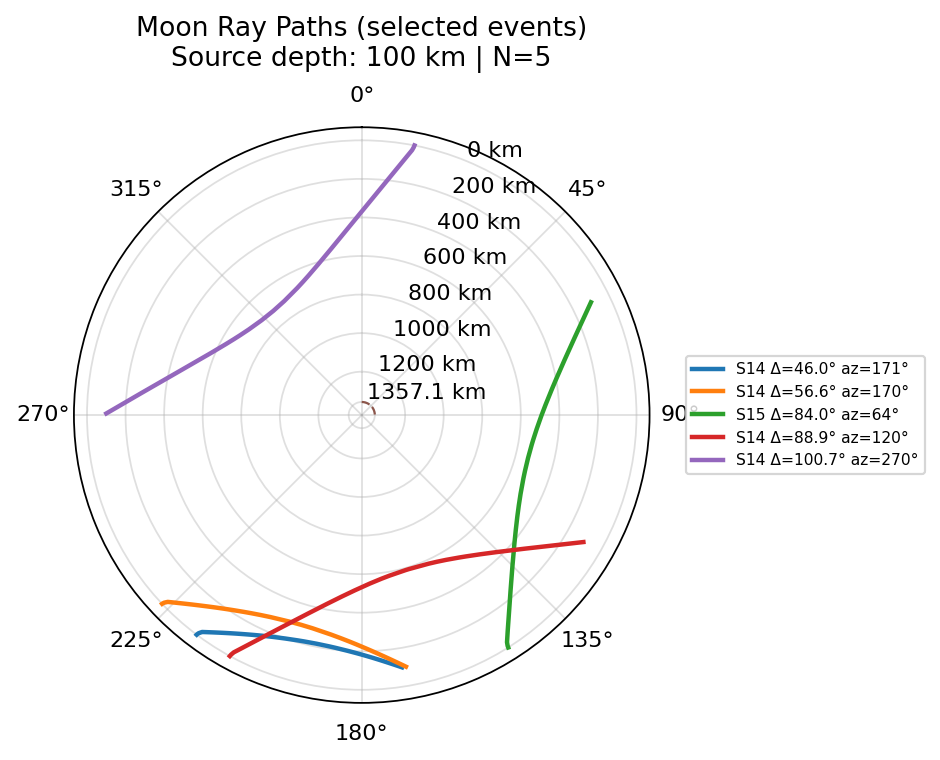

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel

# -------------------------
# INPUTS (from your previous cell)
#   out_df must contain:
#     station, epi_deg, lat, Lon (or lon), and optionally time_utc/event
# -------------------------

# ---- Fill these with the REAL Apollo station coordinates (selenographic deg) ----
APOLLO_STATIONS = {
    "S12": {"lat": -3.01084,  "lon": -23.42456},  # Apollo 12
    "S14": {"lat": -3.64450,  "lon": -17.47753},  # Apollo 14
    "S15": {"lat": 26.13407,  "lon": 3.62981},    # Apollo 15
    "S16": {"lat": -8.97301,  "lon": 15.49812},   # Apollo 16
}

# ---- Moon / TauP config ----
MODEL_NAME   = "vpremoon_mantle_closed"
RMOON_KM     = 1737.1
SOURCE_DEPTH = 100 
PHASE_LIST   = ["P"]

PLOT_FIRST_ARRIVAL_ONLY = True  # keeps plot clean

def azimuth_deg(lat1, lon1, lat2, lon2):
    """Forward azimuth from (lat1,lon1) to (lat2,lon2) in degrees. 0°=N, 90°=E."""
    φ1, λ1, φ2, λ2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])
    dλ = λ2 - λ1
    x = np.sin(dλ) * np.cos(φ2)
    y = np.cos(φ1) * np.sin(φ2) - np.sin(φ1) * np.cos(φ2) * np.cos(dλ)
    az = np.arctan2(x, y)
    return (np.rad2deg(az) + 360.0) % 360.0

def plot_rays_selected_events(out_df):
    # --- normalize column names from your example (lat, Lon) ---
    df = out_df.copy()
    df["station"] = df["station"].astype(str).str.strip()

    if "lon" in df.columns and "Lon" not in df.columns:
        df["Lon"] = df["lon"]

    df["epi_deg"] = pd.to_numeric(df["epi_deg"], errors="coerce")
    df["lat"]     = pd.to_numeric(df["lat"], errors="coerce")
    df["Lon"]     = pd.to_numeric(df["Lon"], errors="coerce")

    # --- filter to rows we can plot ---
    df = df[
        np.isfinite(df["epi_deg"]) &
        np.isfinite(df["lat"]) &
        np.isfinite(df["Lon"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].reset_index(drop=True)

    if df.empty:
        raise ValueError(
            "No rows to plot after filtering. "
            "Check: station names match APOLLO_STATIONS and lat/Lon/epi_deg are finite."
        )

    model = TauPyModel(model=MODEL_NAME)

    fig = plt.figure(figsize=(6, 6), dpi=160)
    ax = plt.subplot(111, projection="polar")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    for _, row in df.iterrows():
        sta = row["station"]
        dist_deg = float(row["epi_deg"])

        ev_lat, ev_lon = float(row["lat"]), float(row["Lon"])
        st_lat = float(APOLLO_STATIONS[sta]["lat"])
        st_lon = float(APOLLO_STATIONS[sta]["lon"])

        # Rotate ray by azimuth so it points toward the station geographically
        az = azimuth_deg(ev_lat, ev_lon, st_lat, st_lon)
        az_rad = np.deg2rad(az)

        arr = model.get_ray_paths(
            source_depth_in_km=SOURCE_DEPTH,
            distance_in_degree=dist_deg,
            phase_list=PHASE_LIST
        )
        if not arr:
            continue

        rays = arr
        if PLOT_FIRST_ARRIVAL_ONLY:
            rays = [min(arr, key=lambda a: a.time)]

        # label (keep short; legend gets big fast)
        label = f"{sta} Δ={dist_deg:.1f}° az={az:.0f}°"

        for a in rays:
            theta = a.path["dist"] + az_rad
            r     = RMOON_KM - a.path["depth"]
            ax.plot(theta, r, linewidth=2, label=label)

    # Depth ticks (labels are depth)
    depth_ticks = [0, 200, 400, 600, 800, 1000, 1200, 1357.1, 1500, 1737.1]
    r_ticks = [RMOON_KM - d for d in depth_ticks]
    ax.set_yticks(r_ticks)
    ax.set_yticklabels([f"{d:g} km" for d in depth_ticks])

    # Mantle boundary arc (optional), up to max Δ
    max_dist_deg = float(df["epi_deg"].max())
    theta_grid = np.linspace(0, np.deg2rad(max_dist_deg), 600)
    mantle_boundary_depth = 1357.1
    r_boundary = RMOON_KM - mantle_boundary_depth
    ax.plot(theta_grid, np.full_like(theta_grid, r_boundary), linestyle="--", linewidth=1)

    ax.set_title(
        f"Moon Ray Paths (selected events)\n"
        f"Source depth: {SOURCE_DEPTH} km | N={len(df)}",
        va="bottom"
    )
    ax.grid(True, alpha=0.4)
    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=7)
    plt.tight_layout()
    plt.show()

# ---- run ----
plot_rays_selected_events(out_df)

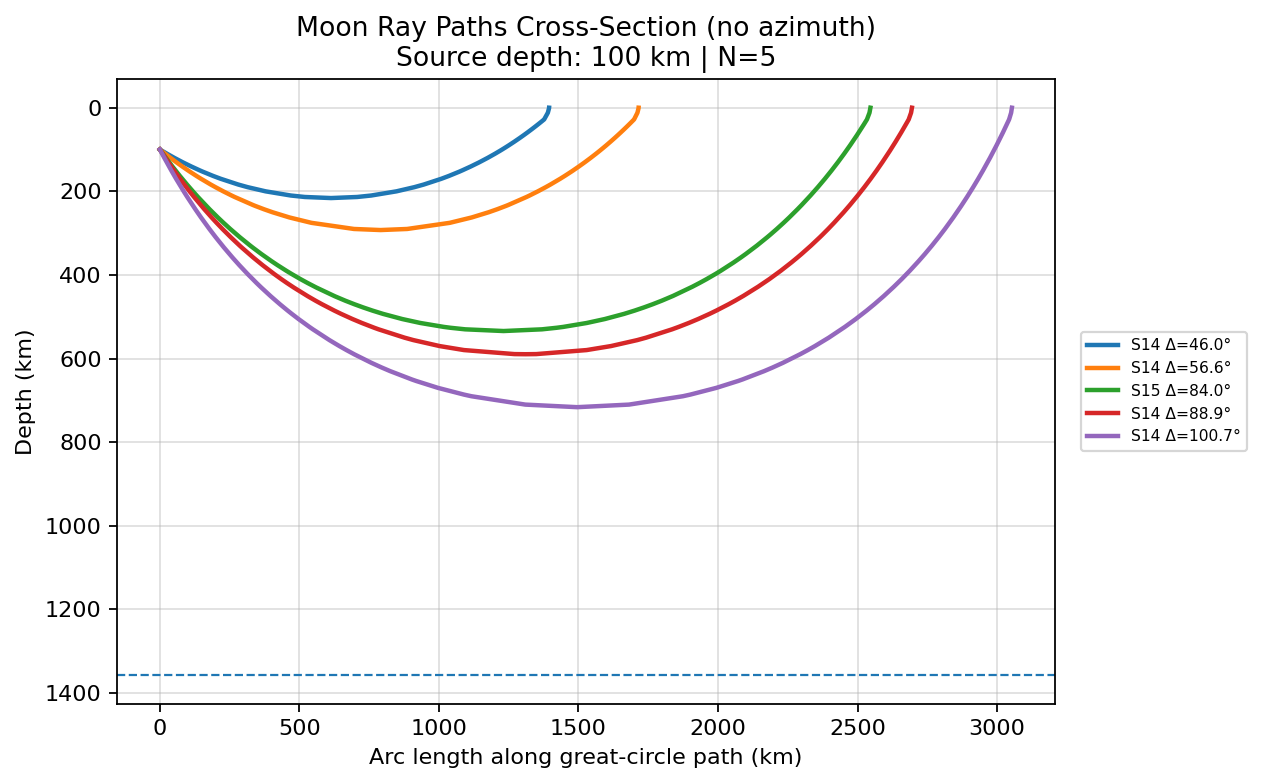

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel

MODEL_NAME   = "vpremoon_mantle_closed"
RMOON_KM     = 1737.1
SOURCE_DEPTH = 100
PHASE_LIST   = ["P"]
PLOT_FIRST_ARRIVAL_ONLY = True

def plot_rays_cross_section(out_df):
    df = out_df.copy()
    df["station"] = df["station"].astype(str).str.strip()

    if "lon" in df.columns and "Lon" not in df.columns:
        df["Lon"] = df["lon"]

    df["epi_deg"] = pd.to_numeric(df["epi_deg"], errors="coerce")
    df["lat"]     = pd.to_numeric(df["lat"], errors="coerce")
    df["Lon"]     = pd.to_numeric(df["Lon"], errors="coerce")

    df = df[
        np.isfinite(df["epi_deg"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].reset_index(drop=True)

    if df.empty:
        raise ValueError("No rows to plot after filtering.")

    model = TauPyModel(model=MODEL_NAME)

    fig, ax = plt.subplots(figsize=(8, 5), dpi=160)

    for _, row in df.iterrows():
        sta = row["station"]
        dist_deg = float(row["epi_deg"])

        arr = model.get_ray_paths(
            source_depth_in_km=SOURCE_DEPTH,
            distance_in_degree=dist_deg,
            phase_list=PHASE_LIST
        )
        if not arr:
            continue

        rays = arr
        if PLOT_FIRST_ARRIVAL_ONLY:
            rays = [min(arr, key=lambda a: a.time)]

        label = f"{sta} Δ={dist_deg:.1f}°"

        for a in rays:
            # TauP path distances are in radians.
            dist_rad = a.path["dist"]
            depth_km = a.path["depth"]

            # Convert angular distance to arc length in km along the sphere
            x_km = RMOON_KM * dist_rad
            y_km = depth_km  # depth positive downward

            ax.plot(x_km, y_km, linewidth=2, label=label)

    # Styling
    ax.invert_yaxis()  # depth increases downward
    ax.set_xlabel("Arc length along great-circle path (km)")
    ax.set_ylabel("Depth (km)")
    ax.set_title(f"Moon Ray Paths Cross-Section (no azimuth)\nSource depth: {SOURCE_DEPTH} km | N={len(df)}")
    ax.grid(True, alpha=0.4)

    # Optional: mantle boundary line at 1357.1 km depth (horizontal)
    mantle_boundary_depth = 1357.1
    ax.axhline(mantle_boundary_depth, linestyle="--", linewidth=1)

    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7)
    plt.tight_layout()
    plt.show()

# run
plot_rays_cross_section(out_df)

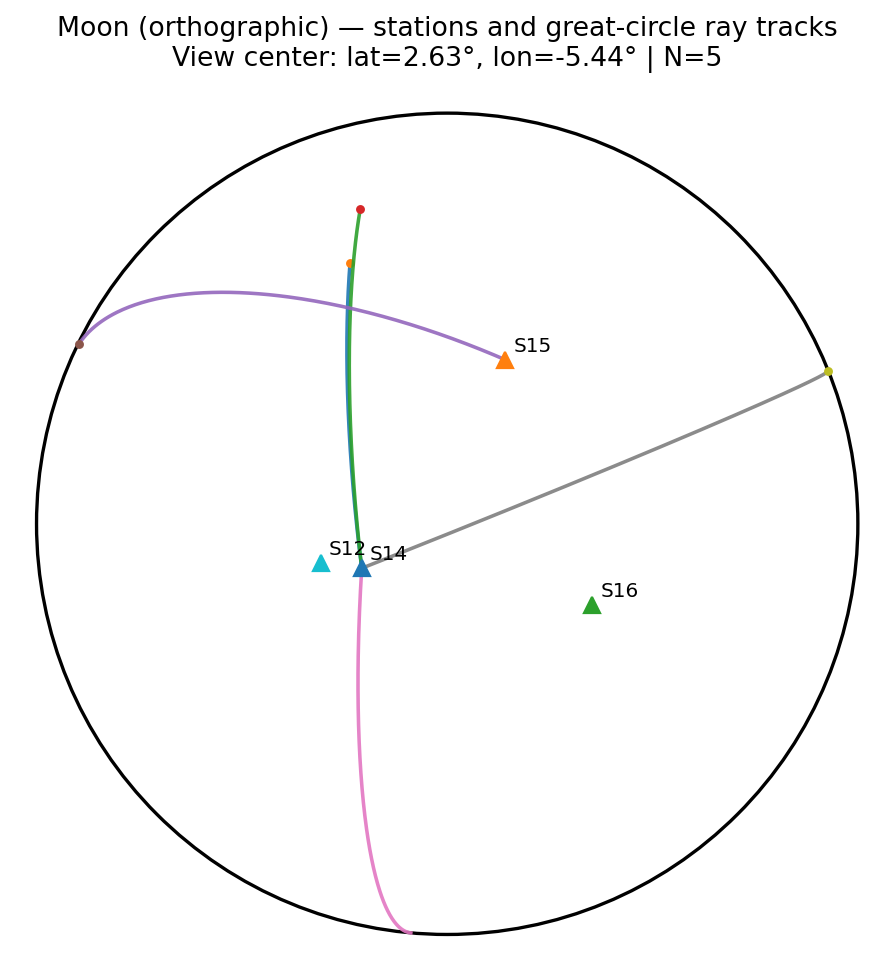

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses your existing APOLLO_STATIONS dict and out_df with columns:
#   station, lat, Lon (or lon)

def _wrap_lon(lon_deg):
    """Wrap longitude to [-180, 180)."""
    lon = (lon_deg + 180) % 360 - 180
    return lon

def _orthographic_project(lat_deg, lon_deg, lat0_deg, lon0_deg, R=1.0):
    """
    Orthographic projection of (lat,lon) onto a plane centered at (lat0,lon0).
    Returns x,y plus a boolean 'visible' (front hemisphere).
    """
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)
    lat0 = np.deg2rad(lat0_deg)
    lon0 = np.deg2rad(lon0_deg)

    dlon = lon - lon0
    # visibility: cos(c) >= 0
    cosc = np.sin(lat0)*np.sin(lat) + np.cos(lat0)*np.cos(lat)*np.cos(dlon)
    visible = cosc >= 0

    x = R * np.cos(lat) * np.sin(dlon)
    y = R * (np.cos(lat0)*np.sin(lat) - np.sin(lat0)*np.cos(lat)*np.cos(dlon))
    return x, y, visible

def _slerp_gc(lat1_deg, lon1_deg, lat2_deg, lon2_deg, n=200):
    """
    Great-circle points from (lat1,lon1) to (lat2,lon2) using spherical linear interpolation.
    Returns arrays of lat, lon in degrees.
    """
    lat1, lon1 = np.deg2rad([lat1_deg, lon1_deg])
    lat2, lon2 = np.deg2rad([lat2_deg, lon2_deg])

    def sph2cart(lat, lon):
        return np.array([np.cos(lat)*np.cos(lon),
                         np.cos(lat)*np.sin(lon),
                         np.sin(lat)])

    p1 = sph2cart(lat1, lon1)
    p2 = sph2cart(lat2, lon2)

    # angle between
    omega = np.arccos(np.clip(np.dot(p1, p2), -1.0, 1.0))
    if np.isclose(omega, 0.0):
        lats = np.full(n, lat1_deg)
        lons = np.full(n, lon1_deg)
        return lats, lons

    t = np.linspace(0, 1, n)
    so = np.sin(omega)
    pts = (np.sin((1-t)*omega)/so)[:, None]*p1[None, :] + (np.sin(t*omega)/so)[:, None]*p2[None, :]

    # back to lat/lon
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]
    lat = np.arctan2(z, np.sqrt(x*x + y*y))
    lon = np.arctan2(y, x)
    return np.rad2deg(lat), np.rad2deg(lon)

def plot_topdown_stations_and_tracks(
    out_df,
    center_lat=None,
    center_lon=None,
    npts=200,
    show_events=True,
    show_station_labels=True
):
    df = out_df.copy()
    df["station"] = df["station"].astype(str).str.strip()

    if "lon" in df.columns and "Lon" not in df.columns:
        df["Lon"] = df["lon"]

    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

    df = df[
        np.isfinite(df["lat"]) &
        np.isfinite(df["Lon"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].reset_index(drop=True)

    if df.empty:
        raise ValueError("No rows to plot after filtering. Check station names and lat/Lon columns.")

    # Default view: center on the mean of station long/lat (keeps stations on the front hemisphere)
    sta_lats = np.array([APOLLO_STATIONS[s]["lat"] for s in APOLLO_STATIONS])
    sta_lons = np.array([_wrap_lon(APOLLO_STATIONS[s]["lon"]) for s in APOLLO_STATIONS])

    if center_lat is None:
        center_lat = float(np.mean(sta_lats))
    if center_lon is None:
        center_lon = float(np.mean(sta_lons))

    fig, ax = plt.subplots(figsize=(7, 7), dpi=160)

    # draw Moon disk
    moon = plt.Circle((0, 0), 1.0, fill=False, linewidth=1.5)
    ax.add_patch(moon)

    # helper: clip to disk
    ax.set_aspect("equal", "box")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.axis("off")

    # plot great-circle tracks
    for i, row in df.iterrows():
        sta = row["station"]
        ev_lat, ev_lon = float(row["lat"]), _wrap_lon(float(row["Lon"]))
        st_lat = float(APOLLO_STATIONS[sta]["lat"])
        st_lon = _wrap_lon(float(APOLLO_STATIONS[sta]["lon"]))

        lats, lons = _slerp_gc(ev_lat, ev_lon, st_lat, st_lon, n=npts)
        x, y, vis = _orthographic_project(lats, lons, center_lat, center_lon, R=1.0)

        # Only draw the visible portion (front hemisphere) to avoid “through the back of the globe”
        x_plot = np.where(vis, x, np.nan)
        y_plot = np.where(vis, y, np.nan)

        ax.plot(x_plot, y_plot, linewidth=1.6, alpha=0.9, label=sta if i == 0 else None)

        # event marker (optional)
        if show_events:
            ex, ey, evis = _orthographic_project(ev_lat, ev_lon, center_lat, center_lon, R=1.0)
            if evis:
                ax.plot(ex, ey, marker="o", markersize=3)

    # plot stations
    for sta, ll in APOLLO_STATIONS.items():
        st_lat = float(ll["lat"])
        st_lon = _wrap_lon(float(ll["lon"]))
        sx, sy, svis = _orthographic_project(st_lat, st_lon, center_lat, center_lon, R=1.0)
        if svis:
            ax.plot(sx, sy, marker="^", markersize=7)
            if show_station_labels:
                ax.text(sx + 0.02, sy + 0.02, sta, fontsize=9)

    ax.set_title(
        f"Moon (orthographic) — stations and great-circle ray tracks\n"
        f"View center: lat={center_lat:.2f}°, lon={center_lon:.2f}° | N={len(df)}",
        pad=12
    )

    plt.show()

# run
plot_topdown_stations_and_tracks(out_df)